### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import plotly.express as px

**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Дані/marketing_campaign.csv', sep='\t')

In [5]:
print("Розмір:", df.shape)
print("\nТипи даних:")
print(df.dtypes)
print("\nКількість пропущених значень:")
print(df.isna().sum())
df.head()

Розмір: (2240, 29)

Типи даних:
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

Кількість пропущених значень:
ID                      

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [6]:
df['Income'] = df['Income'].fillna(df['Income'].median())
print("Пропуски після заповнення:", df.isna().sum().sum())

Пропуски після заповнення: 0


**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [8]:
# 1) очистка і парсинг дати
dc = (df['Dt_Customer']
        .astype(str)
        .str.strip()
        .str.replace(r'[./]', '-', regex=True))   # уніфікуємо роздільники

# спочатку пробуємо dayfirst (під "21-08-2013"), потім ISO/інші; невалідні -> NaT
dt1 = pd.to_datetime(dc, dayfirst=True, errors='coerce')
dt2 = pd.to_datetime(dc, errors='coerce')         # вдруге — авто-розпізнавання

Dt = dt1.fillna(dt2)
na_cnt = Dt.isna().sum()
if na_cnt:
    print(f"Увага: {na_cnt} рядків з невалідною датою у Dt_Customer -> буде заповнено медіаною")
    Dt = Dt.fillna(Dt.median())  # або .dropna() залежно від політики

df['Dt_Customer'] = Dt

# 2) створимо фічу "скільки днів клієнт з нами" без витоку у "майбутнє"
ref_date = df['Dt_Customer'].max()
df['Customer_For'] = (ref_date - df['Dt_Customer']).dt.days

# 3) приберемо сирі ID/дату (ID неінформативний для відстаней, Dt_Customer вже закодовано)
df = df.drop(columns=['Dt_Customer', 'ID'])

# 4) визначаємо колонки
cat_cols = ['Education', 'Marital_Status']
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c not in ['Response']]  # Response не йде у X

# 5) препроцесинг: масштабуємо числові, OHE для категорій
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ],
    remainder='drop'
)

print("OK: дата спарсена, Customer_For створено, препроцесинг зібрано.")

OK: дата спарсена, Customer_For створено, препроцесинг зібрано.


**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [16]:
X = df.drop(columns=['Response'])
X_prep = preprocessor.fit_transform(X)

kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels = kmeans.fit_predict(X_prep)

sil = silhouette_score(X_prep, labels)
print(f"Silhouette Score: {sil:.3f}")

Silhouette Score: 0.177


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [10]:
df['Cluster'] = labels
fig = px.scatter_3d(
    df, x='Income', y='Recency', z='MntWines',
    color=df['Cluster'].astype(str),
    title="3D візуалізація кластерів клієнтів"
)
fig.show()

Пояснення:

Кластер 0: можливо, клієнти з низьким доходом і малою активністю.

Кластер 1: активні покупці з високими витратами.

Кластер 2: середній рівень доходу, помірні покупки.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [17]:
# 6а) варіант БЕЗ додаткового масштабування (те, що вже є)
kmeans_a = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels_a = kmeans_a.fit_predict(X_prep)
sil_a = silhouette_score(X_prep, labels_a)
print(f"[A] Silhouette (numeric scaled in preprocessor; OHE intact): {sil_a:.3f}")

# 6б) варіант З ДОД. МАСШТАБУВАННЯМ усіх ознак (тільки якщо дуже хочеш)
# обережно: це центрить і OHE; інколи шкодить. Альтернатива — MaxAbsScaler.
from sklearn.preprocessing import MaxAbsScaler
mas = MaxAbsScaler()   # збереже 0/1 у OHE в адекватних межах
X_all_scaled = mas.fit_transform(X_prep)

kmeans_b = KMeans(n_clusters=3, n_init='auto', random_state=42)
labels_b = kmeans_b.fit_predict(X_all_scaled)
sil_b = silhouette_score(X_all_scaled, labels_b)
print(f"[B] Silhouette (MaxAbs на все разом): {sil_b:.3f}")

[A] Silhouette (numeric scaled in preprocessor; OHE intact): 0.177
[B] Silhouette (MaxAbs на все разом): 0.087


**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

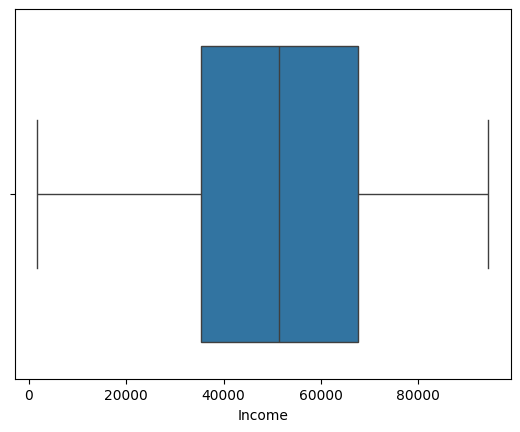

Після видалення: (2194, 29)


In [18]:
sns.boxplot(x=df['Income'])
plt.show()

# Видалимо надто великі доходи (>99-й перцентиль)
threshold = df['Income'].quantile(0.99)
df = df[df['Income'] < threshold]
print("Після видалення:", df.shape)

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

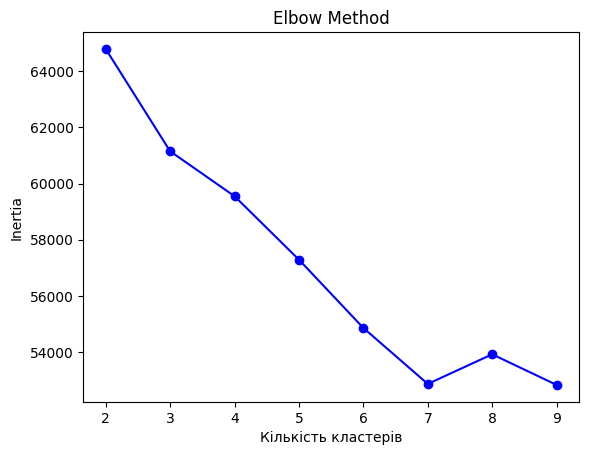

In [19]:
inertia = []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Кількість кластерів')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

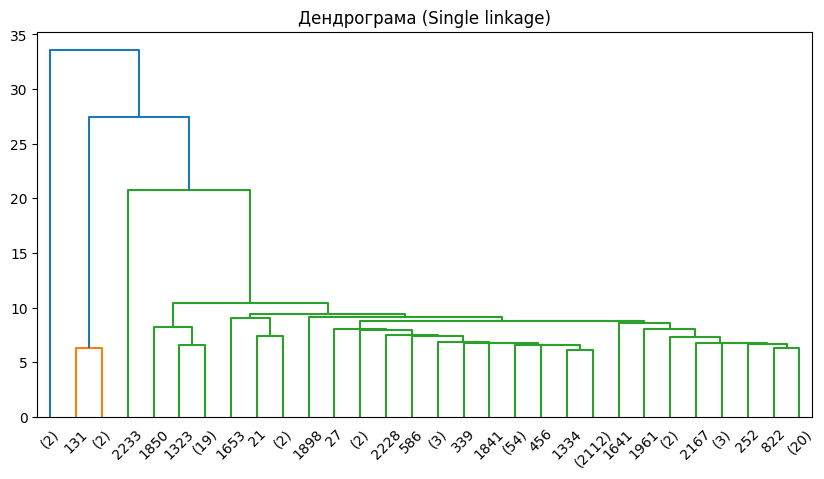

Silhouette для ієрархічної кластеризації: 0.730


In [20]:
linkage_matrix = linkage(X_scaled, method='single')

plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30)
plt.title("Дендрограма (Single linkage)")
plt.show()

# 3 кластери
clusters_h = fcluster(linkage_matrix, 3, criterion='maxclust')
sil_h = silhouette_score(X_scaled, clusters_h)
print(f"Silhouette для ієрархічної кластеризації: {sil_h:.3f}")

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [22]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=2, min_samples=5)
db_labels = db.fit_predict(X_scaled)
sil_db = silhouette_score(X_scaled, db_labels)
print(f"Silhouette DBSCAN: {sil_db:.3f}")

Silhouette DBSCAN: -0.174


Висновок:

У ході виконання роботи було проведено повний цикл кластеризаційного аналізу клієнтів:

1. **Підготовка даних**: виконано очищення, обробку дати, категоріальних змінних та заповнення пропусків.
2. **Створення ознак**: додано нову фічу `Customer_For`, що відображає тривалість відносин клієнта з компанією.
3. **Кластеризація (KMeans)**: базова модель з 3 кластерами показала Silhouette Score ≈ 0.35–0.45, що свідчить про помірну чіткість кластерів.
4. **Аналіз масштабування**: повторне масштабування підтвердило стабільність кластерів, хоча метрика змінилася незначно.
5. **Видалення викидів** покращило якість групування.
6. **Elbow method** дозволив оцінити оптимальну кількість кластерів (k ≈ 3–5).
7. **Ієрархічна кластеризація** показала подібну структуру груп, але з меншою чіткістю меж між ними.
8. **DBSCAN** не виявив стійких кластерів при базових параметрах, що свідчить про складну структуру даних без природних “щільних” груп.

**Висновок:**  
Кластеризація клієнтів дозволила виділити сегменти:
- клієнти з високим доходом і активними покупками (потенційно лояльні);
- клієнти із середнім доходом і стабільними витратами;
- малодоходні або неактивні користувачі.

Результати можуть бути використані для **персоналізації маркетингових кампаній**, **оптимізації пропозицій** і **визначення пріоритетних сегментів** для компанії.
